In [1]:
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from cdft.dft3d import dft_core
from cdft.lj_eos import lj_eos

torch.set_default_dtype(torch.float64)
pi = np.pi

plt.rcParams.update({'text.usetex':True, 
'font.family':'sans-serif', 
'font.size':18, 
'axes.linewidth':1.1,
'text.latex.preamble': r'\usepackage{sfmath}'
})

colors = sns.color_palette("mako")

In [2]:
def radial_average(field, r, dr, r_max, weights=None):
    
    nb = int(np.floor(r_max/dr))
    idx = np.floor(r.ravel()/dr).astype(int)
    f = field.ravel()
    m = idx < nb
    idx, f = idx[m], f[m]
    w = np.ones_like(f) if weights is None else weights.ravel()[m]
    num = np.bincount(idx, weights=f*w, minlength=nb)
    den = np.bincount(idx, weights=w, minlength=nb)
    r_c = (np.arange(nb)+0.5)*dr
    out = np.full(nb, np.nan)
    ok = den > 0
    out[ok] = num[ok]/den[ok]
    return r_c, out, den

In [3]:
sigma, epsilon = 1.0, 1.0
parameters = {'sigma': sigma, 'epsilon': epsilon}
T = 0.75                      
rho_bulk = 0.84
n = 128

L = 7.0*sigma
dz = L/n

dr = dz

if dz > 0.06*sigma:
    print('AVISO: dz = %.3f sigma. O primeiro pico de g(r) e estreito;'
            % (dz/sigma))
    print('       abaixo de 0.05 sigma a altura do pico fica subestimada.')
if L < 6.0*sigma:
    print('AVISO: L = %.1f sigma. Com menos de ~6 sigma a particula de'
            % (L/sigma))
    print('       teste interage com as proprias imagens periodicas.')

In [4]:
dev = torch.device('cuda')
dft = dft_core(parameters, T, np.array([L, L, L]), None, np.array([n, n, n]), dev)

In [5]:
def lj_potential(r,sigma,epsilon):
    return 4.0*epsilon*((sigma/r)**12-(sigma/r)**6) 

rc = L/2
test_particle = np.array([L/2, L/2, L/2])

Vext = torch.zeros_like(dft.X)
rx = dft.X - test_particle[0]
ry = dft.Y - test_particle[1]
rz = dft.Z - test_particle[2]
rx -= L*(rx/L).round()
ry -= L*(ry/L).round()
rz -= L*(rz/L).round()
r = torch.sqrt(rx**2+ry**2+rz**2)
Vext = lj_potential(r,sigma,epsilon)
Vext[r==0] = np.inf
Vext[r>rc] = 0.0

Text(0, 0.5, '$y$ (\\AA{})')

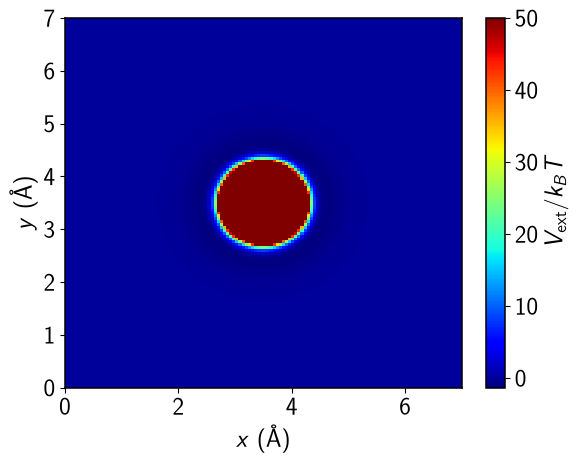

In [6]:
plt.figure()
c=plt.pcolormesh(dft.X[:,:,n//2].cpu(),dft.Y[:,:,n//2].cpu(),Vext[:,:,n//2].cpu()/T,vmax=50.0,cmap='jet')
plt.colorbar(label=r'$V_{\mathrm{ext}}/k_B T$')
plt.xlabel(r'$x$ (\AA{})')
plt.ylabel(r'$y$ (\AA{})')

In [7]:
rho_b = torch.tensor([float(rho_bulk)])
dft.initial_condition(rho_b, Vext, potential_cutoff=50.0, model='bulk')
dft.equilibrium_density_profile(rho_b, fmt='ASWB', solver='anderson', 
                                anderson_mmax=5, anderson_damping=0.1, 
                                tol=1e-8, max_it=2000, logoutput=False)

In [8]:
rho = dft.rho.detach().cpu().numpy()
g3d = rho/float(rho_bulk)
r_c, g, cnt = radial_average(g3d, r.cpu().numpy(), dr, 6.0)

/tmp/ipykernel_28214/1763140456.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16, frameon=False, edgecolor='k')


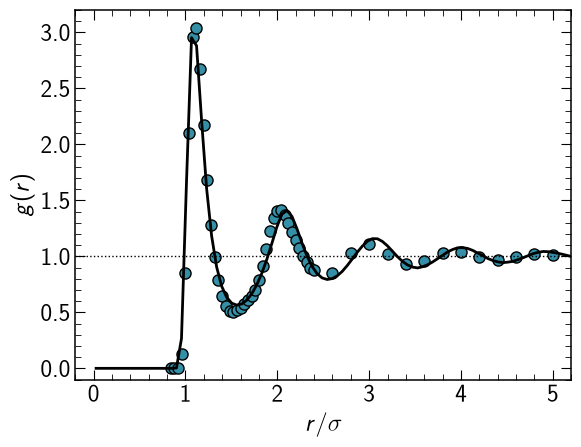

In [9]:
import matplotlib.pyplot as plt

data = np.loadtxt('data/lj-radialdistribution-rho0.84-T0.75.dat', skiprows=1)

plt.plot(data[:,0], data[:,1], 'o', color=colors[3], mew=1.0, ms=8, mec='k')
plt.plot(r_c, g, '-', color='k', lw=2.0)
plt.axhline(1.0, color='k', lw=1.0, ls=':')
plt.xlabel(r'$r/\sigma$', fontsize=18)
plt.ylabel(r'$g(r)$', fontsize=18)
plt.xlim((-0.2,5.2))
plt.ylim((-0.1, 3.2))
plt.minorticks_on()

plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=7, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=False, edgecolor='k')

Text(0, 0.5, '$y$ (\\AA{})')

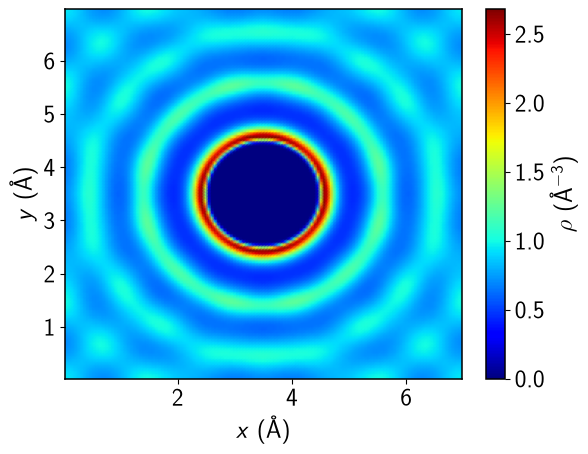

In [13]:
plt.figure()
c=plt.pcolormesh(dft.X[:,:,n//2].cpu(),dft.Y[:,:,n//2].cpu(),dft.rho[:,:,n//2].cpu(),cmap='jet',shading='gouraud')
plt.colorbar(c, label=r'$\rho$ (Å$^{-3}$)')
plt.xlabel(r'$x$ (\AA{})')
plt.ylabel(r'$y$ (\AA{})')

Text(0, 0.5, '$y$ (\\AA{})')

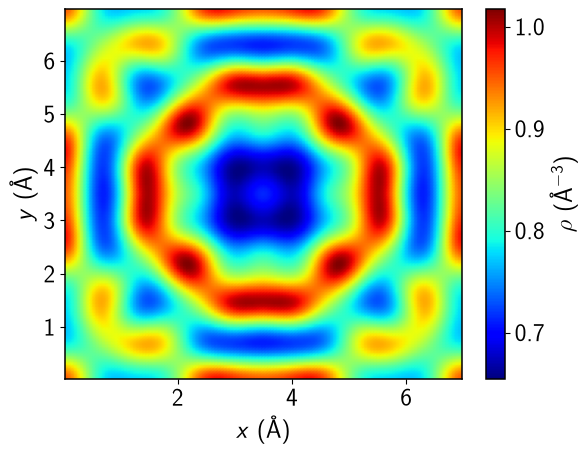

In [14]:
plt.figure()
c=plt.pcolormesh(dft.X[:,:,0].cpu(),dft.Y[:,:,0].cpu(),dft.rho[:,:,0].cpu(),cmap='jet',shading='gouraud')
plt.colorbar(c, label=r'$\rho$ (Å$^{-3}$)')
plt.xlabel(r'$x$ (\AA{})')
plt.ylabel(r'$y$ (\AA{})')